In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
!pip install ultralytics supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.153 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6358.1/8062.4 GB disk)


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="U9OjoGG45S0NKmL2vKPC")
project = rf.workspace("yolov8-xddjz").project("phone-detect-xtmk4")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


RoboflowError: {
    "error": {
        "message": "Unsupported request. `GET /yolov8-xddjz/phone-detect-xtmk4` does not exist or cannot be loaded due to missing permissions.",
        "type": "GraphMethodException",
        "hint": "You can see your active workspace by issuing a GET request to `/` with your `api_key`."
    }
}

In [4]:
!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=100 imgsz=640 plots=True

100%|███████████████████████████████████████| 18.4M/18.4M [00:00<00:00, 135MB/s]
Ultralytics 8.3.75 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/kaggle/working/Phone-Detect-1/data.yaml, epochs=2, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_fr

In [5]:
!ls runs/detect/train

args.yaml					  results.png
confusion_matrix_normalized.png			  train_batch0.jpg
confusion_matrix.png				  train_batch1.jpg
events.out.tfevents.1739592435.c5fc68a1bfc3.85.0  train_batch2.jpg
F1_curve.png					  val_batch0_labels.jpg
labels_correlogram.jpg				  val_batch0_pred.jpg
labels.jpg					  val_batch1_labels.jpg
P_curve.png					  val_batch1_pred.jpg
PR_curve.png					  val_batch2_labels.jpg
R_curve.png					  val_batch2_pred.jpg
results.csv					  weights


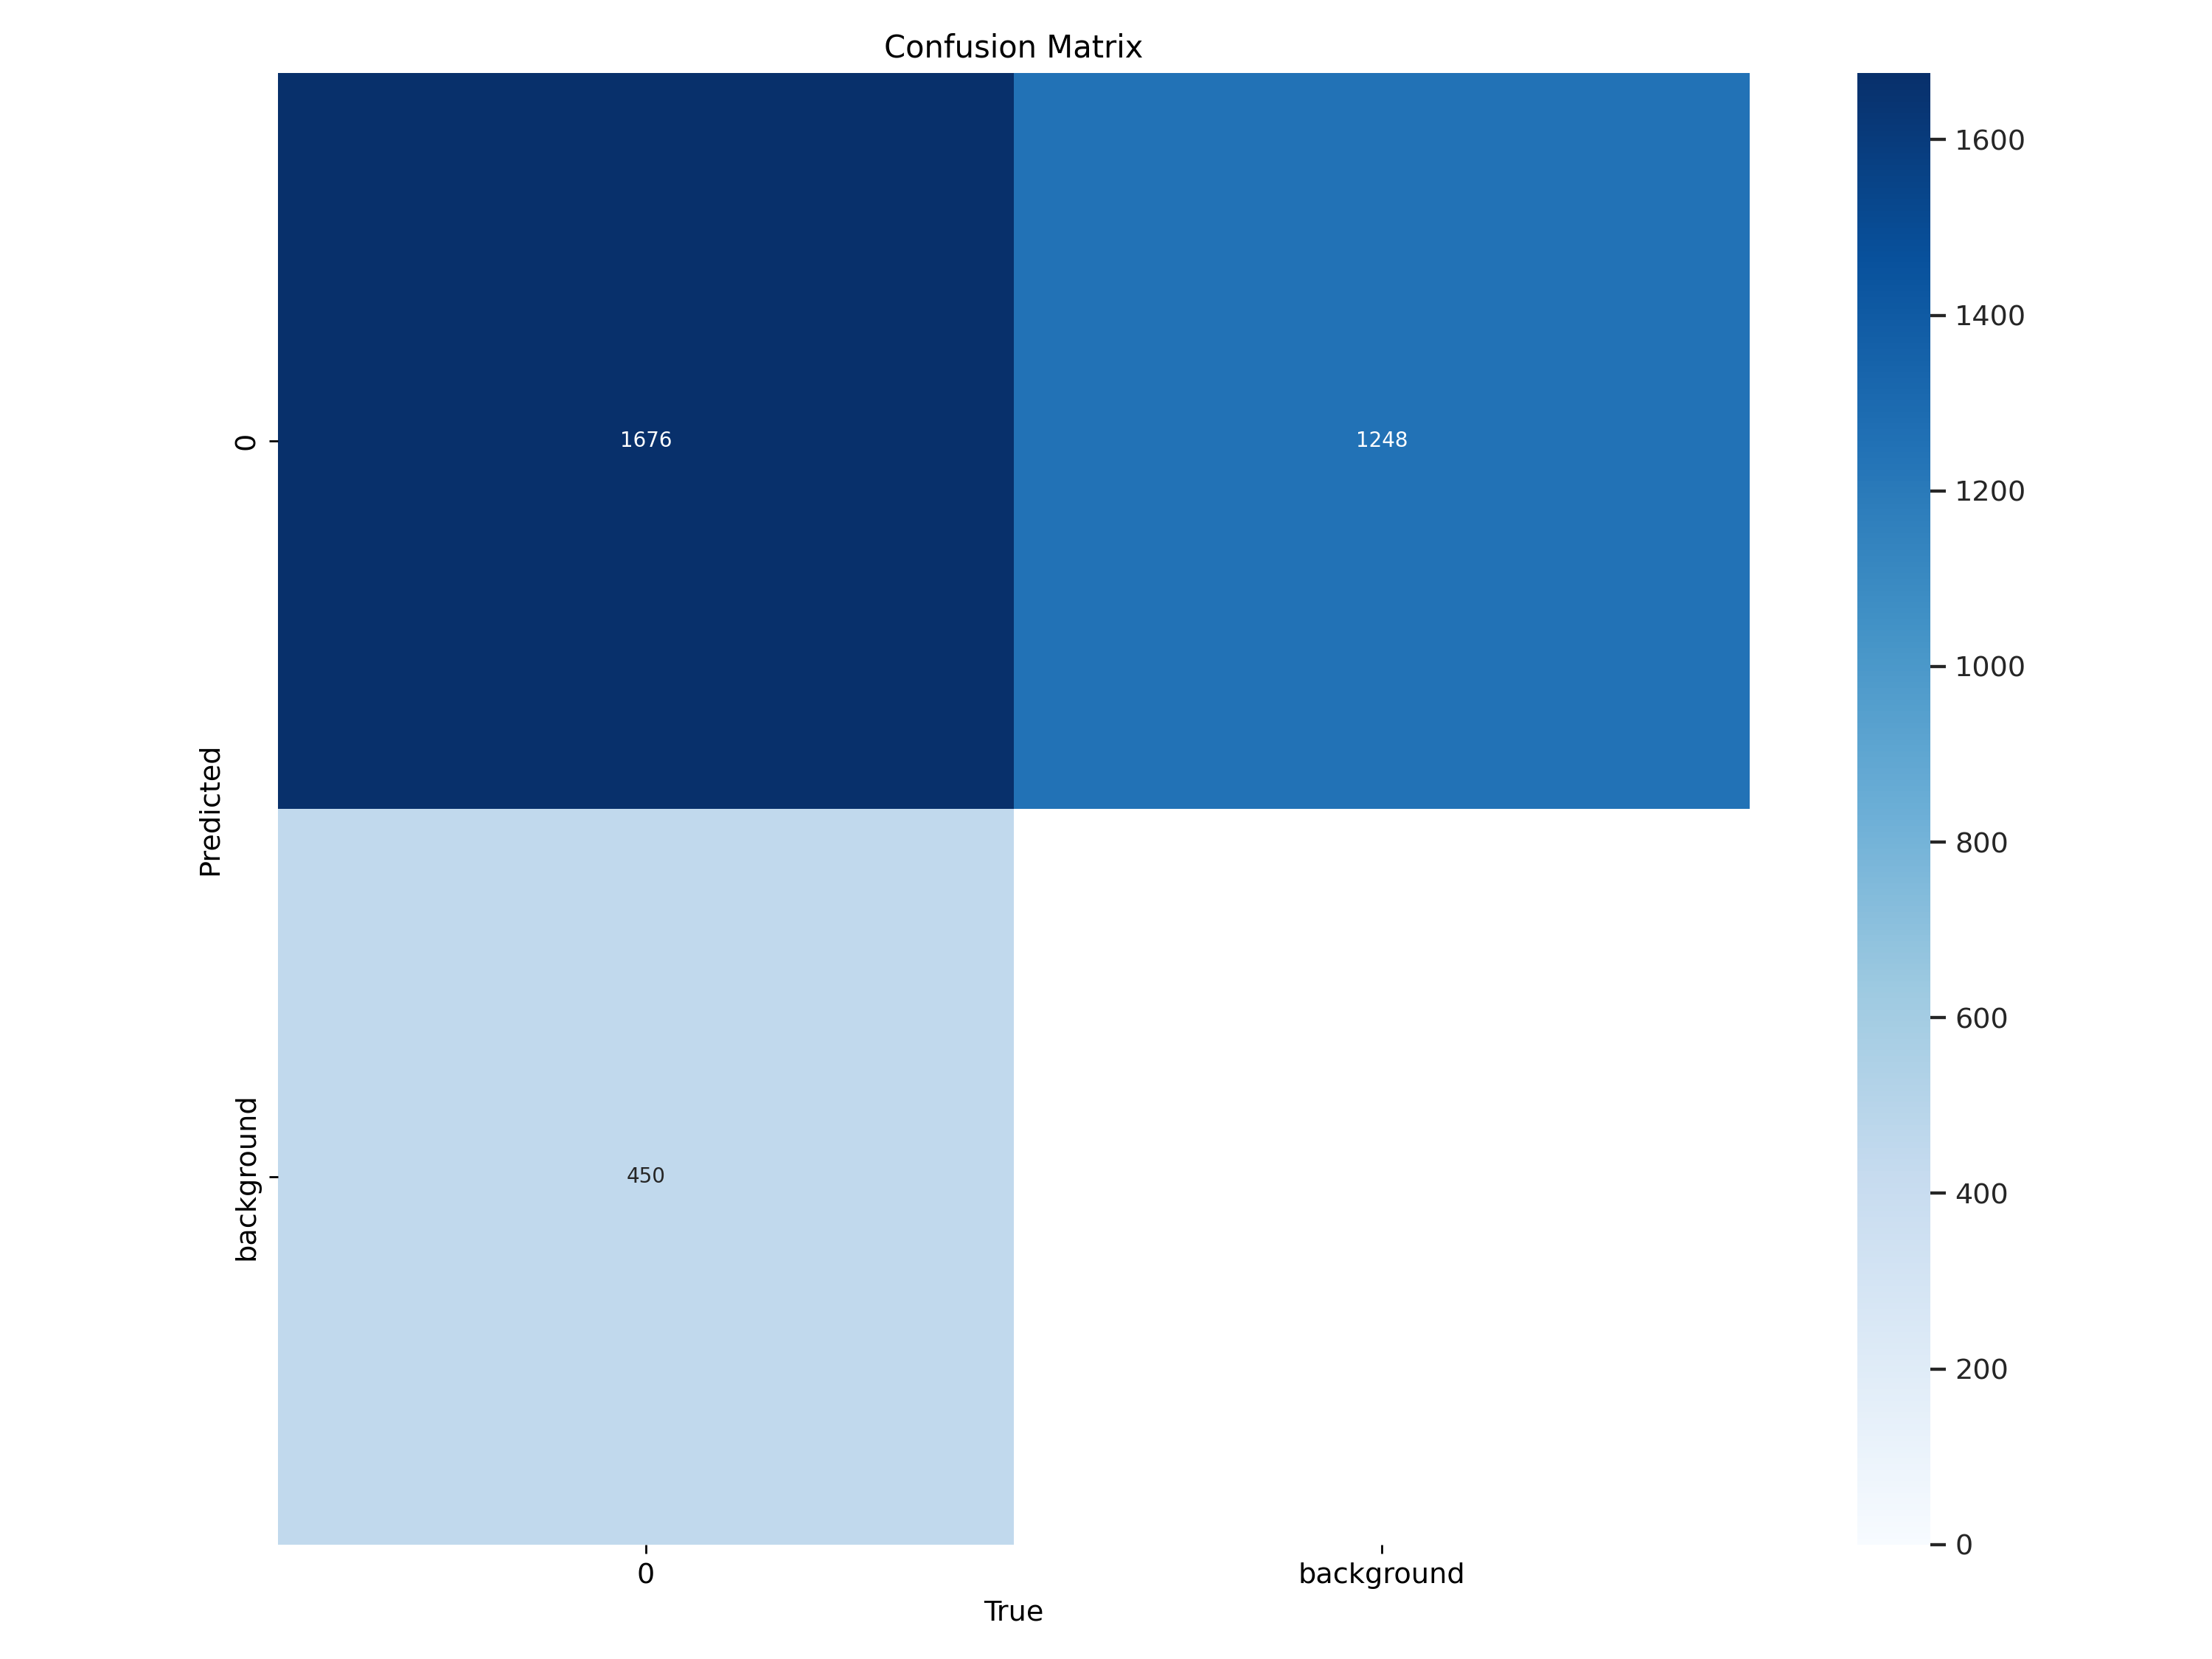

In [6]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'runs/detect/train/confusion_matrix.png', width=600)

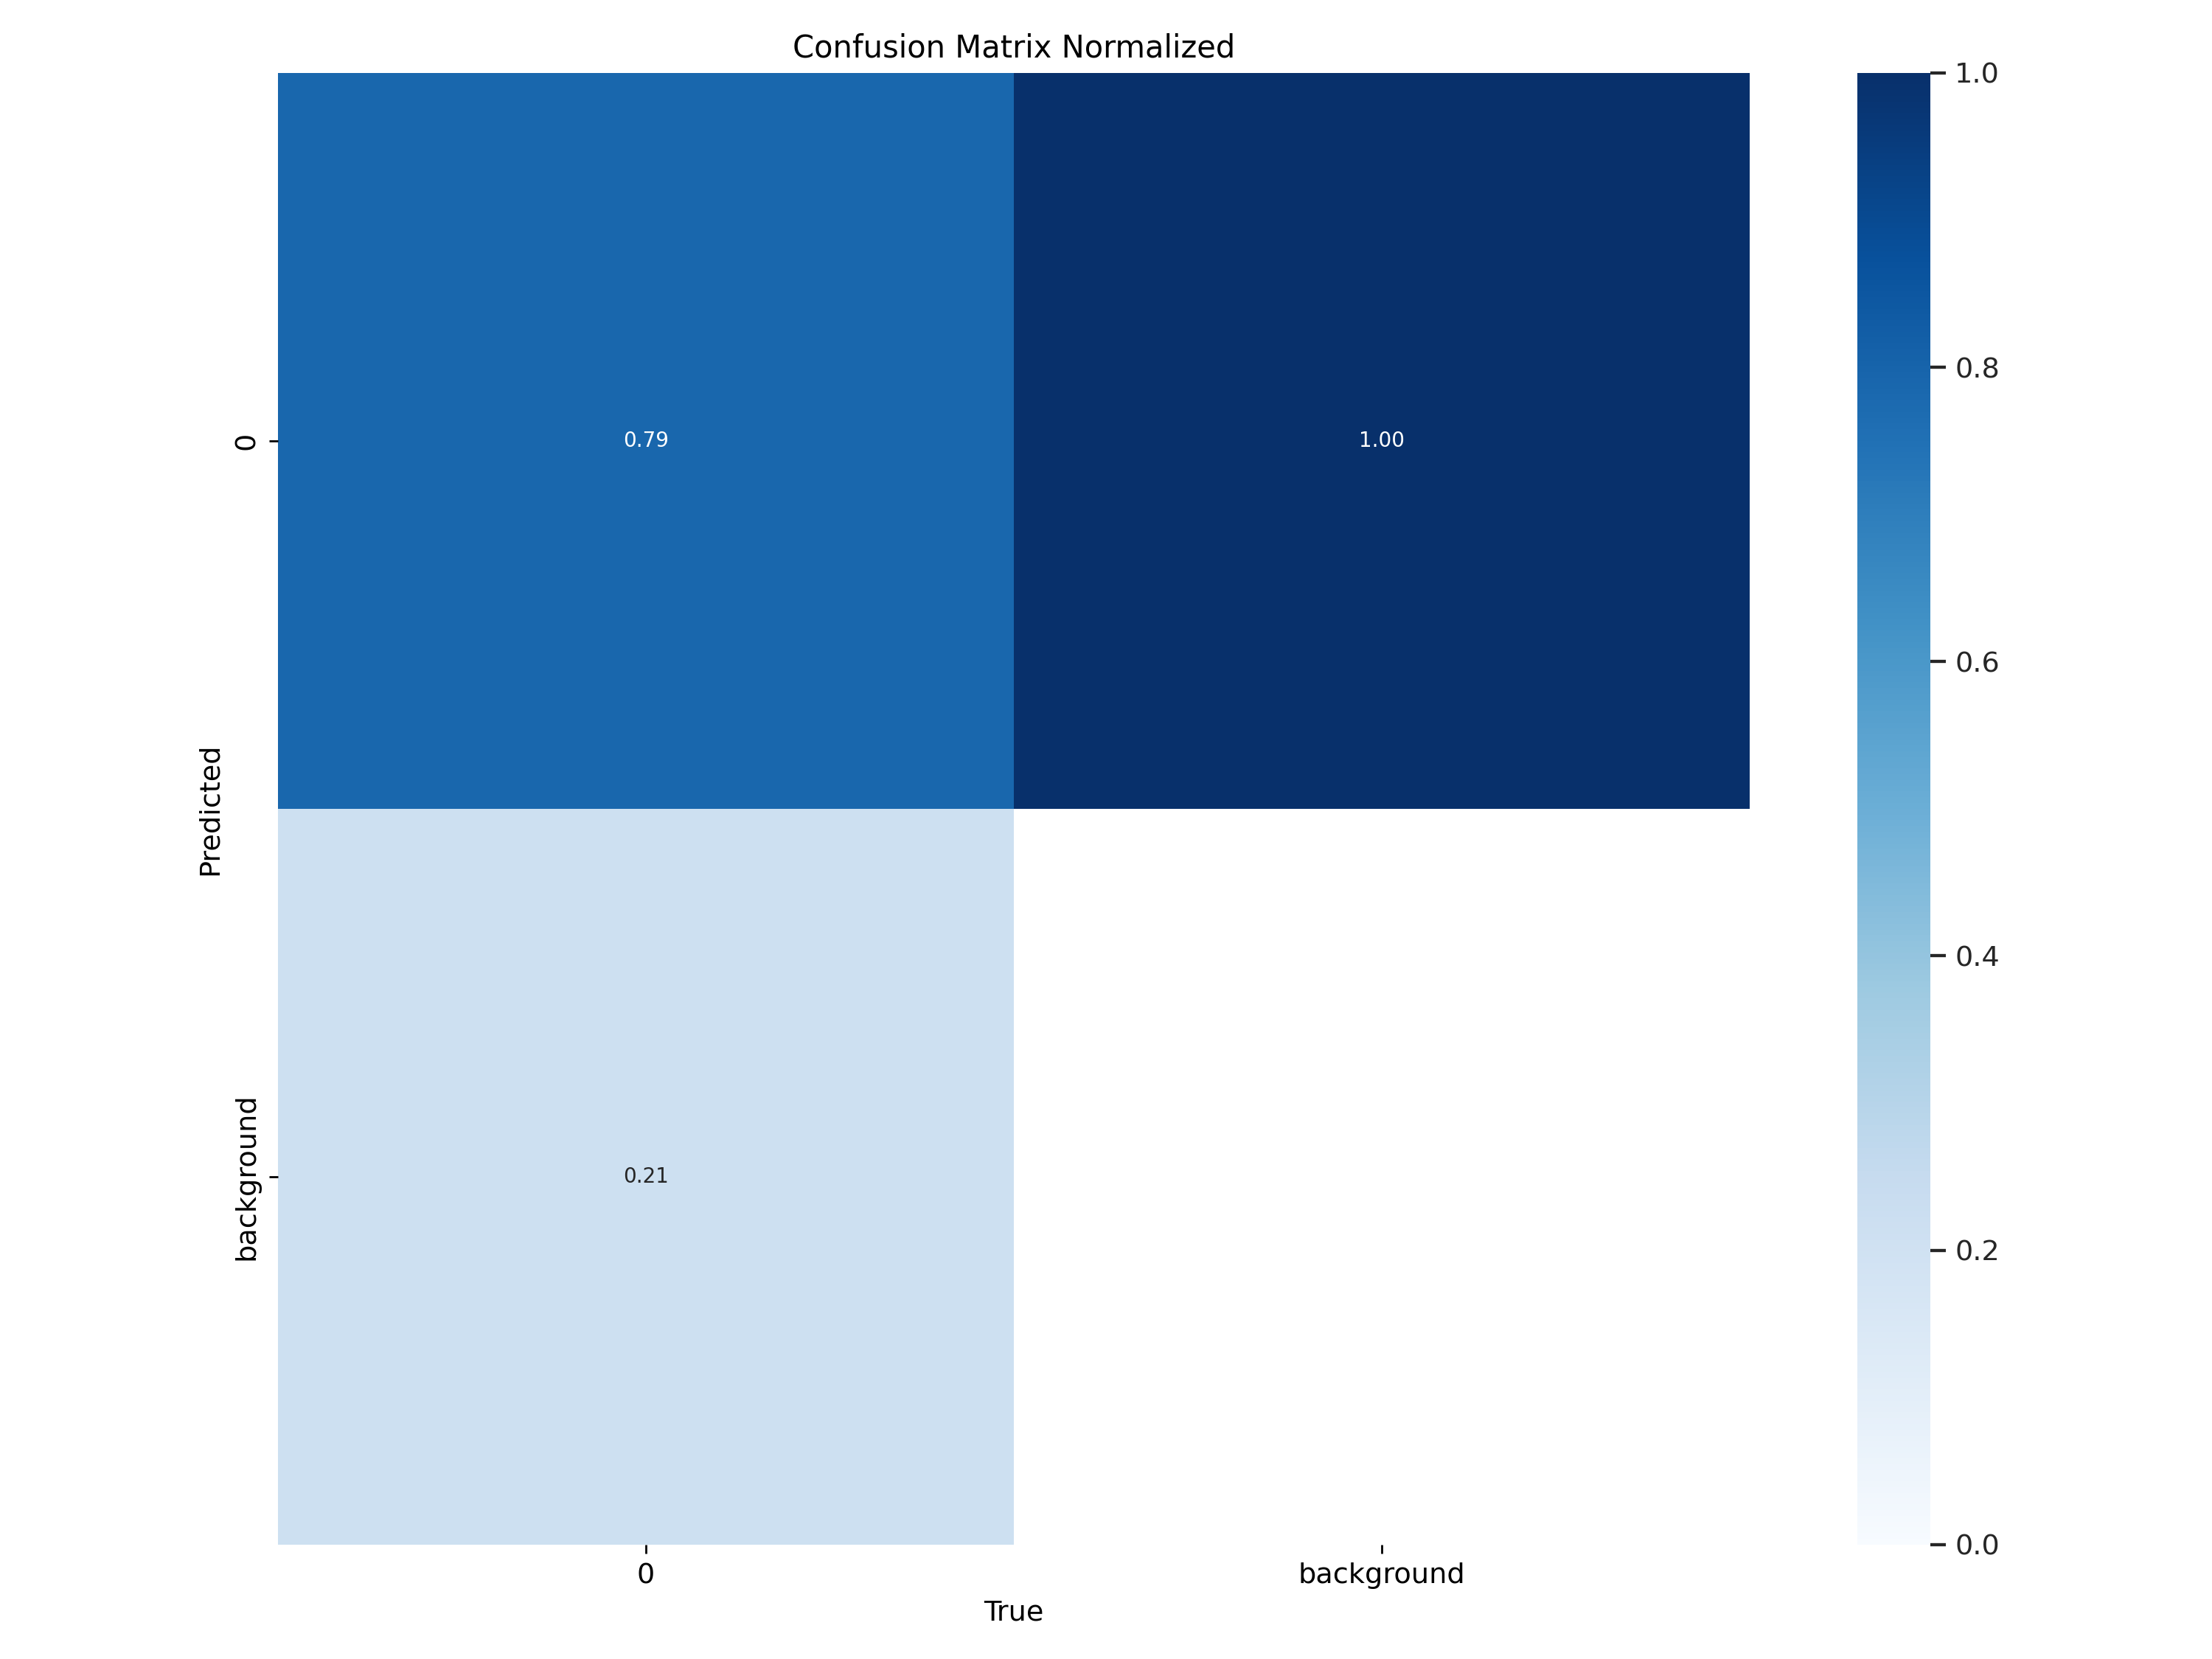

In [7]:
IPyImage(filename=f'runs/detect/train/confusion_matrix_normalized.png', width=600)

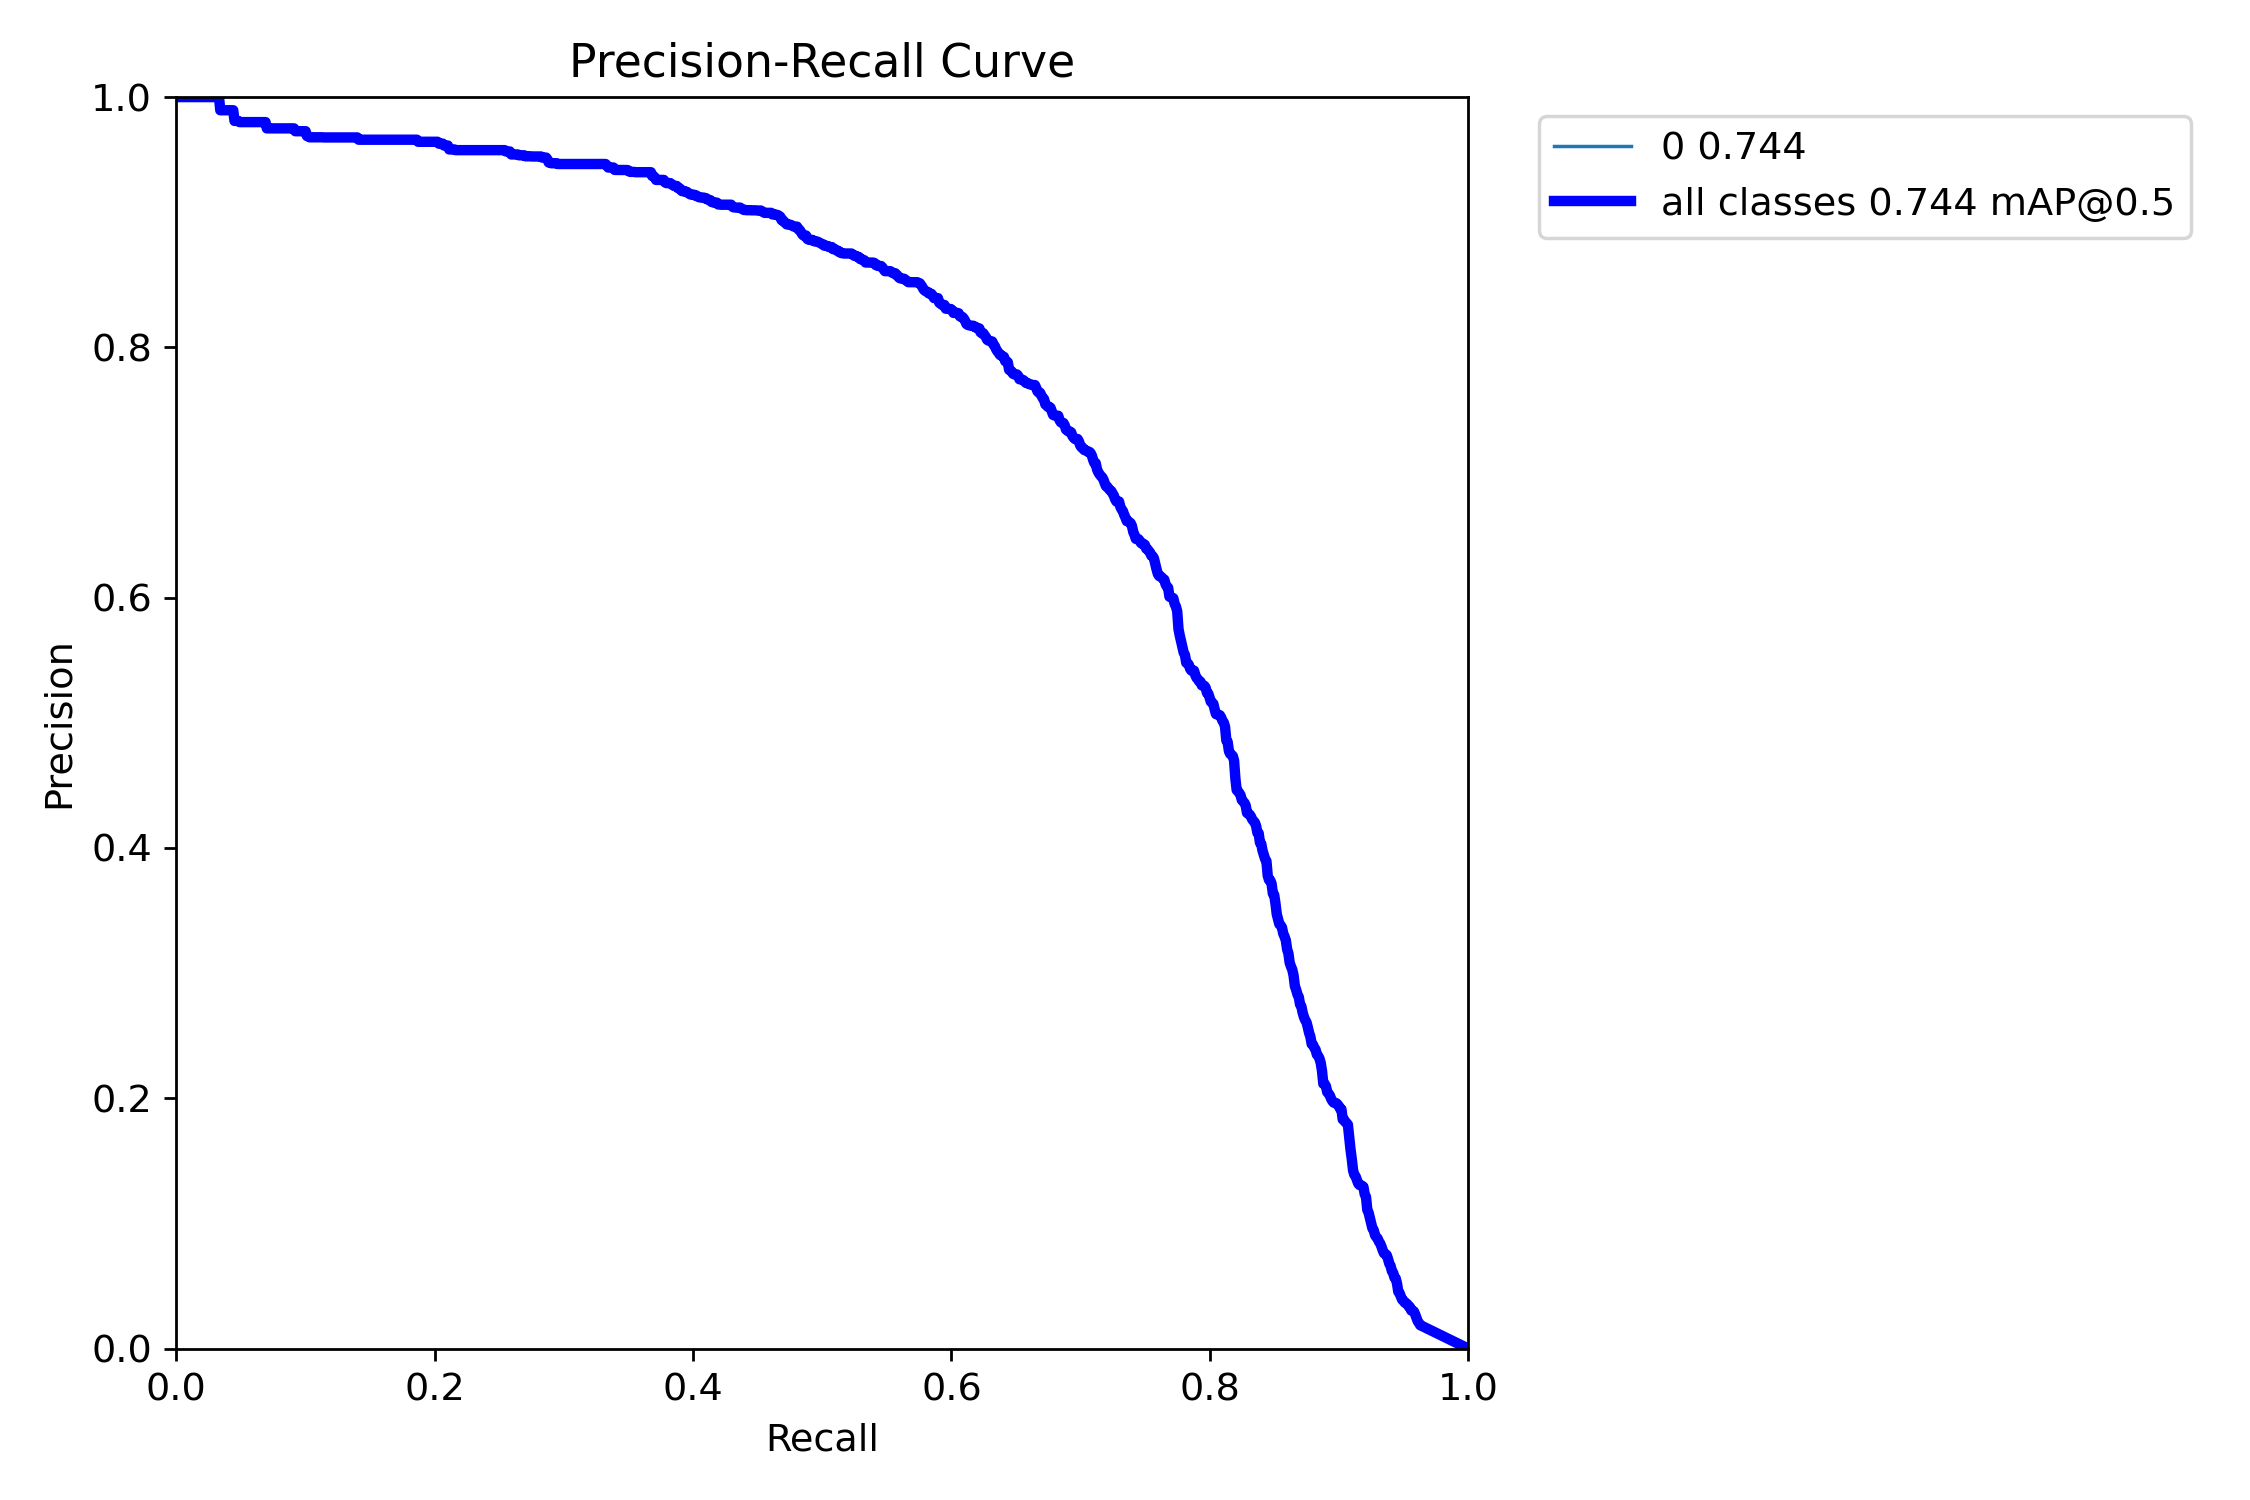

In [8]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'runs/detect/train/PR_curve.png', width=600)

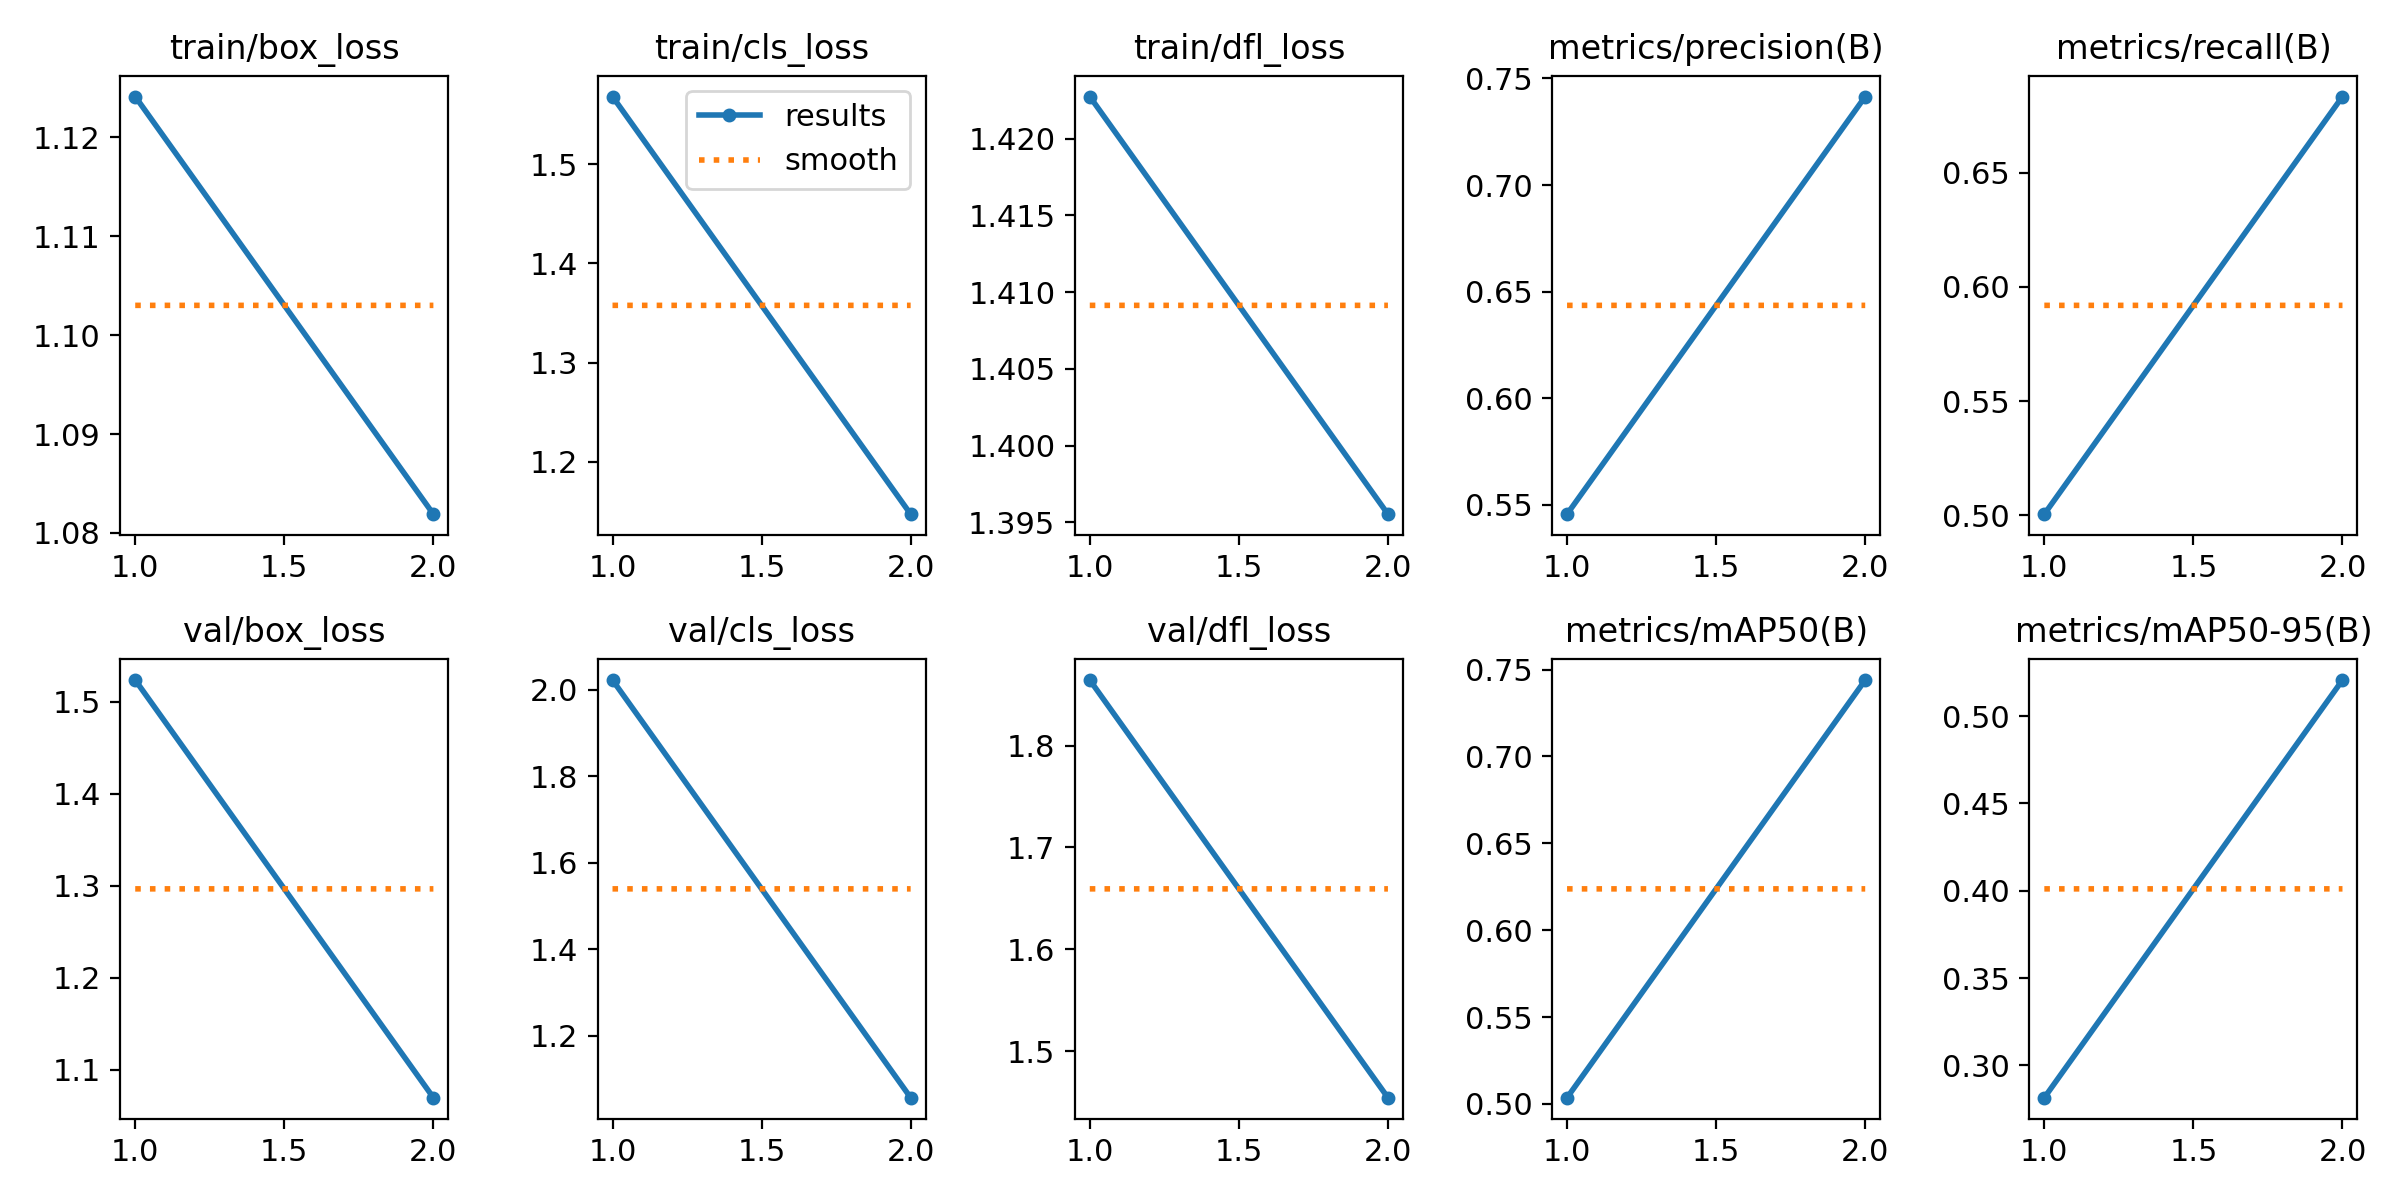

In [9]:
IPyImage(filename=f'runs/detect/train/results.png', width=600)

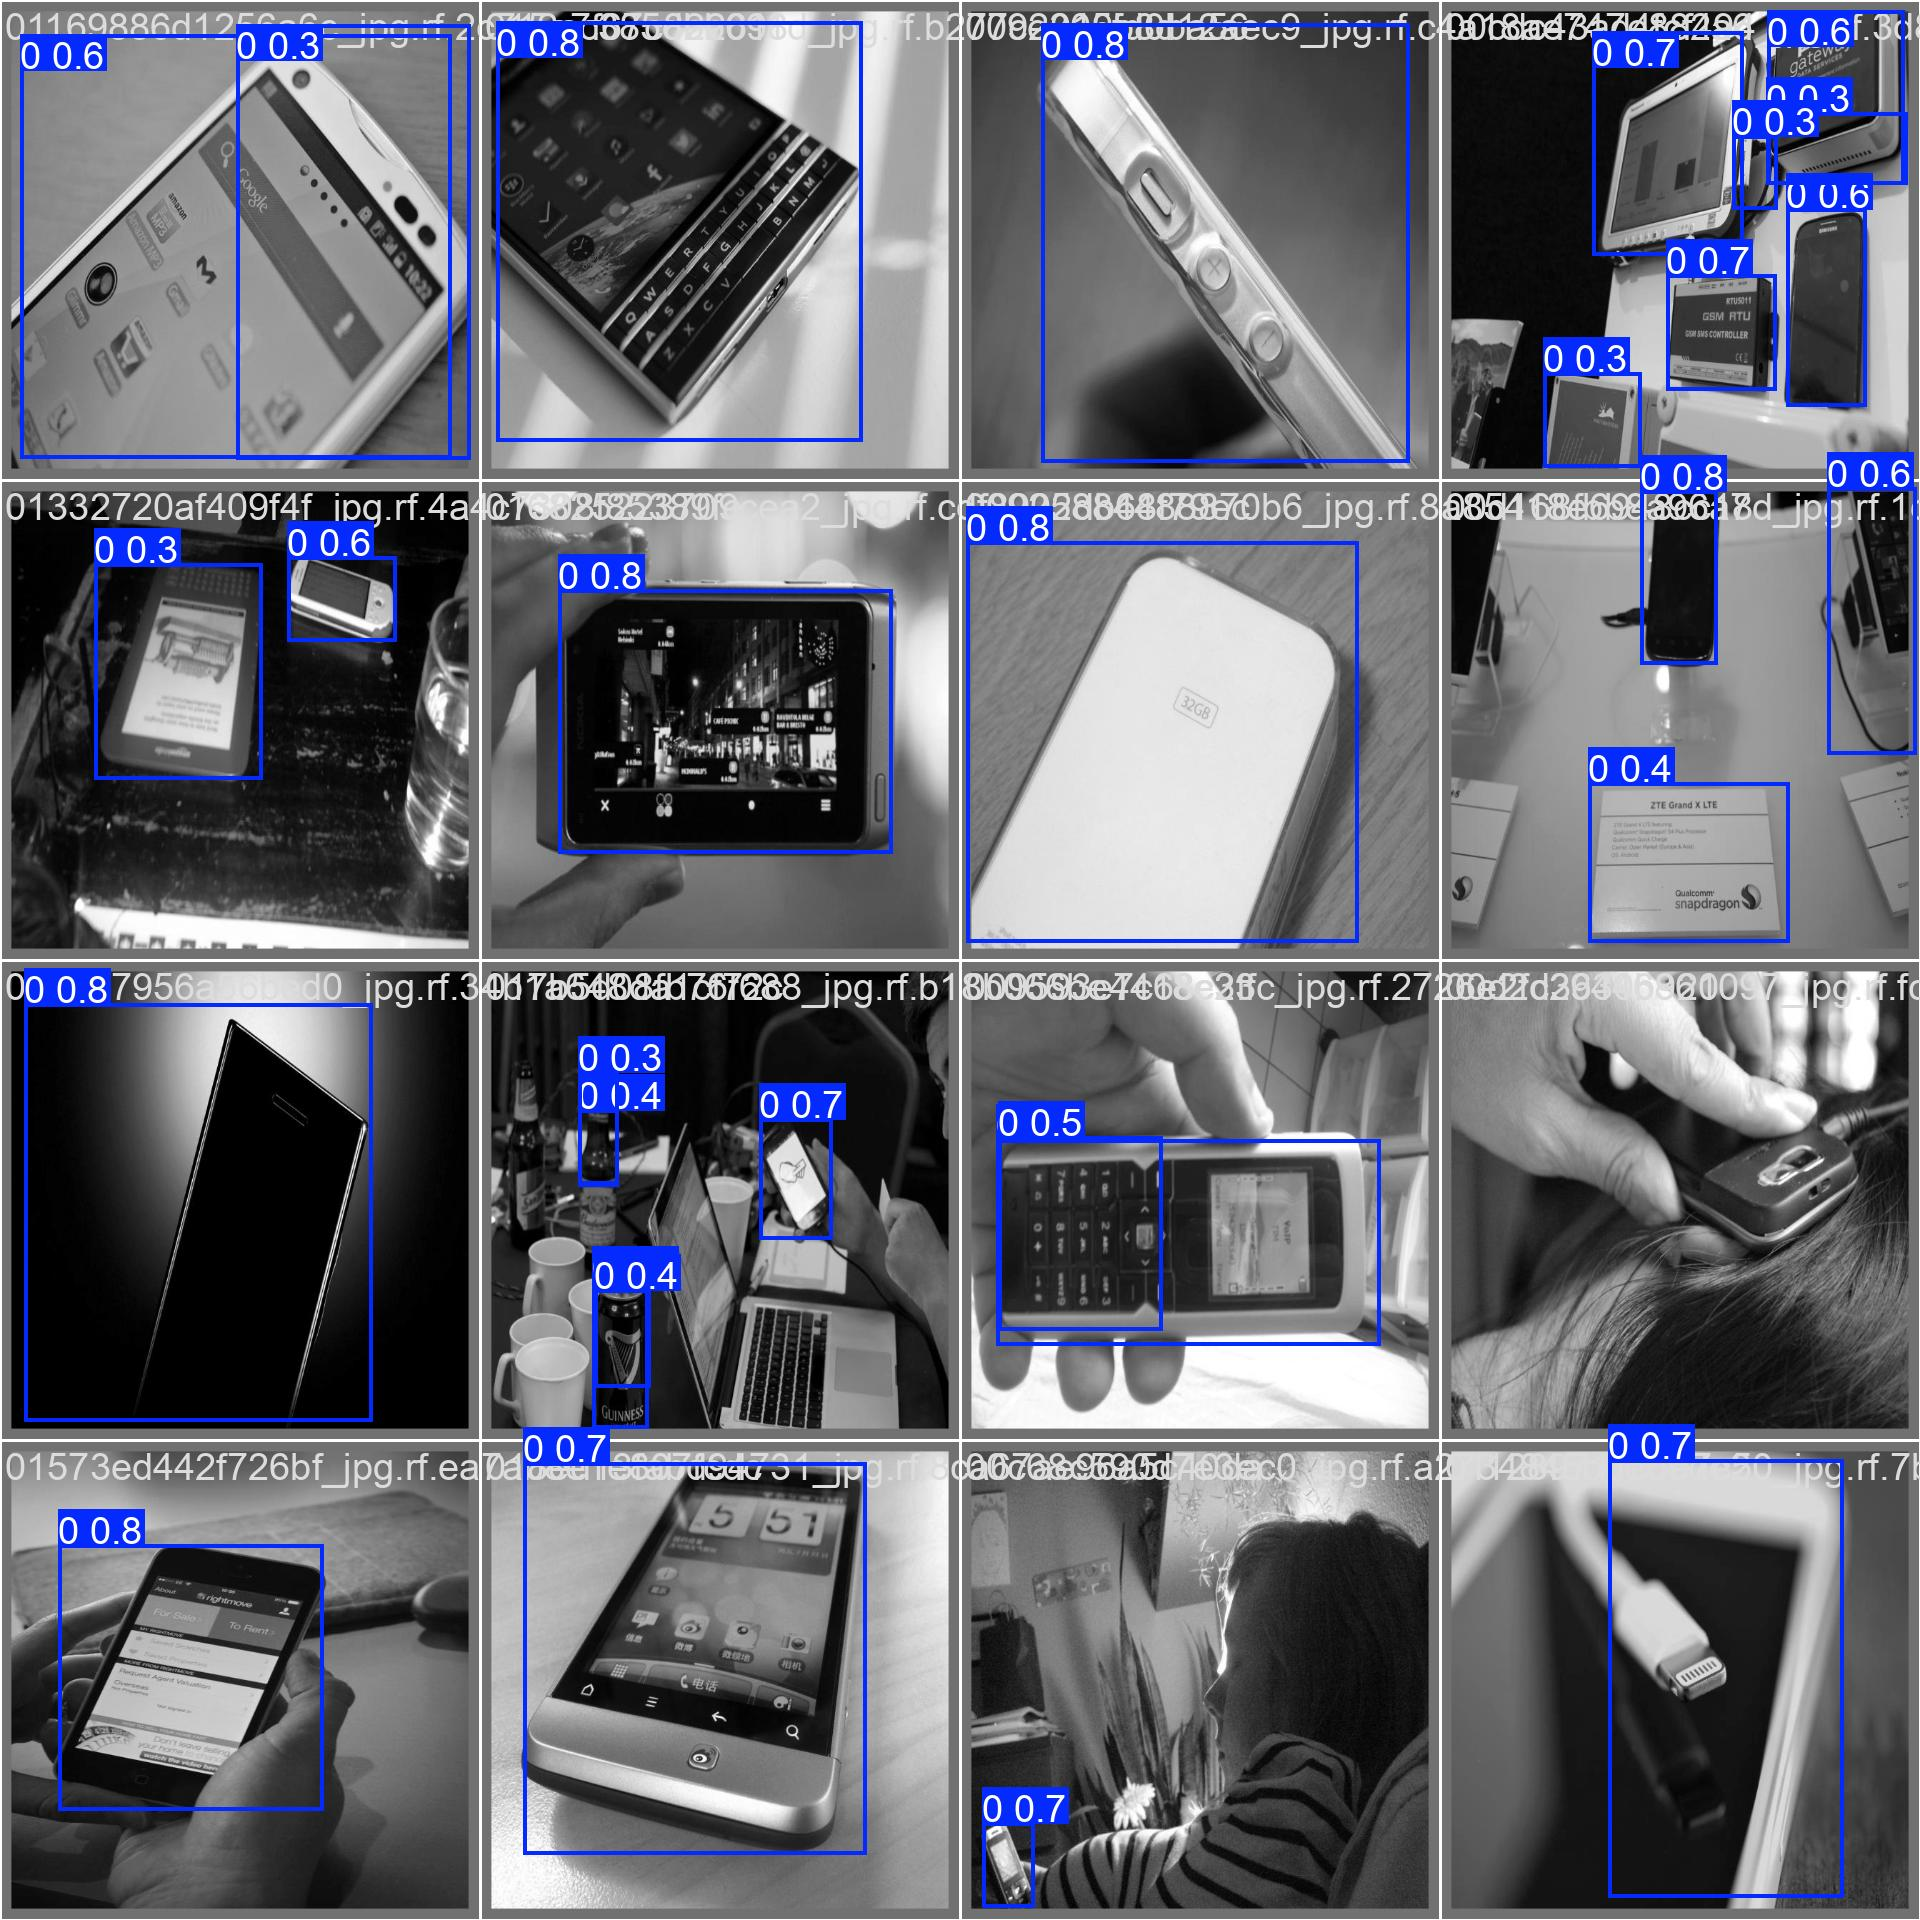

In [10]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'runs/detect/train/val_batch1_pred.jpg', width=600)

In [11]:
!yolo task=detect mode=predict model=runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.75 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/348 /kaggle/working/Phone-Detect-1/test/images/00115506f32aa051_jpg.rf.6bb4e9760324da8495342ee33d82f094.jpg: 640x640 1 0, 12.2ms
image 2/348 /kaggle/working/Phone-Detect-1/test/images/00209998b801428e_jpg.rf.4f3820a7125626e1ee89f8c265c28108.jpg: 640x640 1 0, 9.2ms
image 3/348 /kaggle/working/Phone-Detect-1/test/images/0033d09deafc7bcd_jpg.rf.27e7d8b4a657701818fc9787509886b5.jpg: 640x640 1 0, 9.0ms
image 4/348 /kaggle/working/Phone-Detect-1/test/images/005cb9e795fa91de_jpg.rf.009850f1f972ddd21fc662d37bb052f1.jpg: 640x640 1 0, 9.2ms
image 5/348 /kaggle/working/Phone-Detect-1/test/images/008780d91774e5f1_jpg.rf.f01c002c4e6038d1fb12a2c825709d58.jpg: 640x640 1 0, 9.1ms
image 6/348 /kaggle/working/Phone-Detect-1/test/images/00d8c28fd20b58c8_jpg.rf.077fdc72f9fa09eedb710cf8319fd904.jpg: 640x640 1 0, 9.2ms
imag

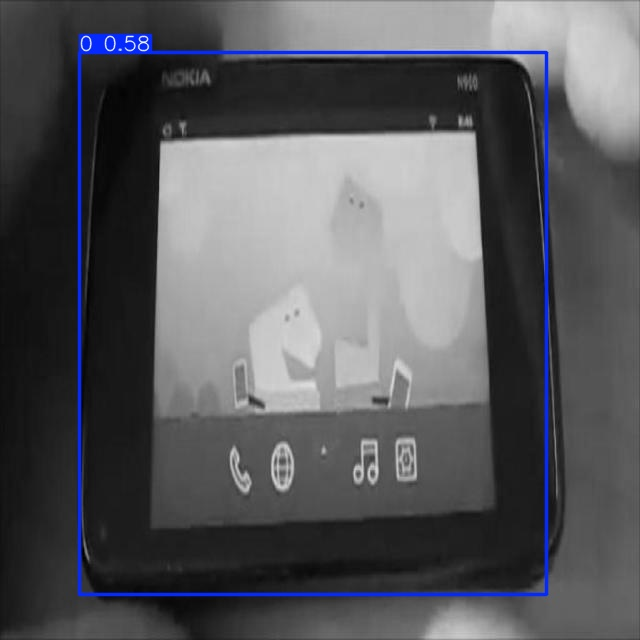

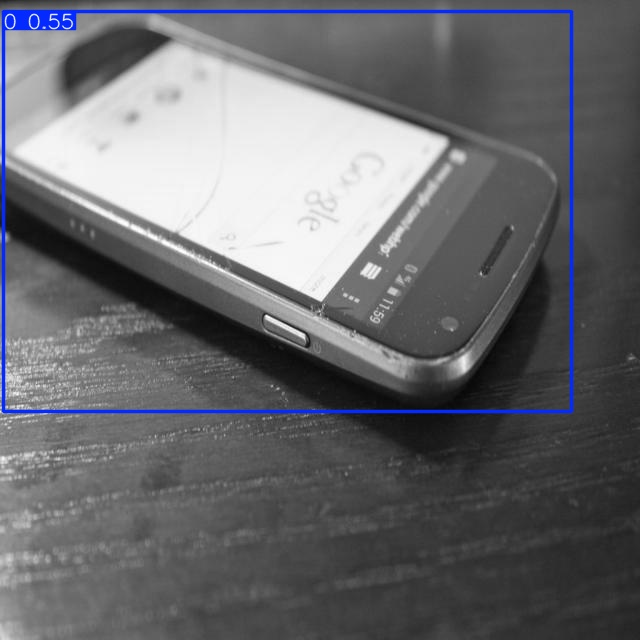

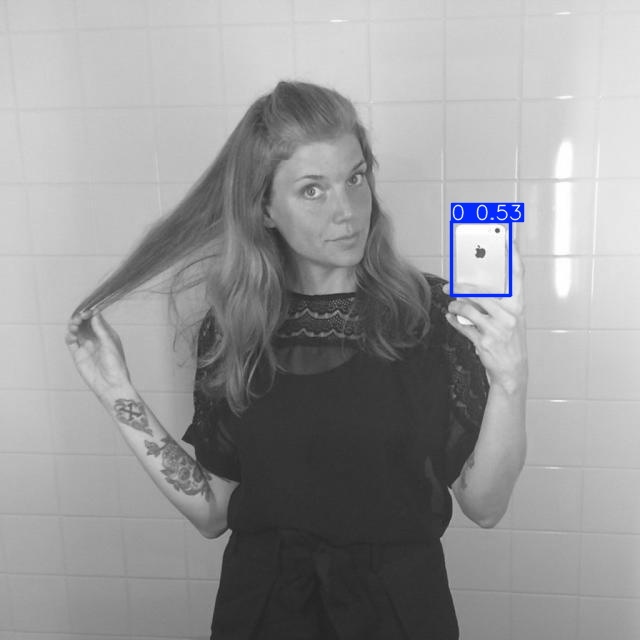

In [12]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [15]:
test_image = "/kaggle/working/Phone-Detect-1/test/images/00209998b801428e_jpg.rf.4f3820a7125626e1ee89f8c265c28108.jpg"

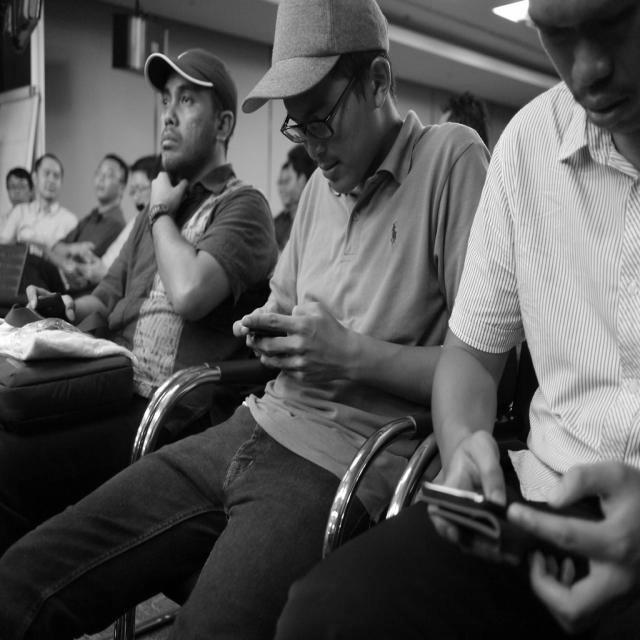

In [16]:
display(IPyImage(filename=test_image, width=600))

# Extracting ROI and Getting Color

In [17]:
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

def detect_and_extract_roi(image_path, model_path="yolov8n.pt", output_dir="output"):
    """
    Detect objects using YOLO, extract the bounding box regions, and save them as separate images.
    """
    try:
        # Load YOLO model
        model = YOLO(model_path)

        # Run YOLO inference
        results = model(image_path)[0]

        # Load image
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Image at path {image_path} could not be loaded.")

        # Convert image to RGB for display
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Check if any objects were detected
        if not results.boxes:
            print("No objects detected.")
            return

        # Create output directory if it doesn't exist
        import os
        os.makedirs(output_dir, exist_ok=True)

        # Iterate over detected objects
        for i, box in enumerate(results.boxes):
            cls_id = int(box.cls.item())  # Class ID
            conf = float(box.conf.item())  # Confidence score
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())  # Bounding box coordinates

            # Crop detected region
            roi = image[y1:y2, x1:x2]

            # Save the cropped image
            output_path = os.path.join(output_dir, f"roi_{i}.jpg")
            cv2.imwrite(output_path, roi)
            print(f"Saved ROI to {output_path}")

            # Display the cropped image
            #cv2_imshow(roi)
            #cv2.waitKey(0)
            #cv2.destroyAllWindows()

            return roi

    except Exception as e:
        print(f"An error occurred: {e}")

# Example Usage
roi = detect_and_extract_roi(test_image, "runs/detect/train/weights/best.pt", "output_rois")


image 1/1 /kaggle/working/Phone-Detect-1/test/images/00209998b801428e_jpg.rf.4f3820a7125626e1ee89f8c265c28108.jpg: 640x640 1 0, 10.1ms
Speed: 5.4ms preprocess, 10.1ms inference, 165.3ms postprocess per image at shape (1, 3, 640, 640)
Saved ROI to output_rois/roi_0.jpg


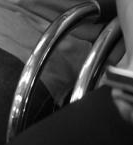

In [18]:
cv2_imshow(roi)